In [46]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# IMPORTANDO DADOS

In [47]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,time,target_wz,target_tmp,target_pitch,target_e,target_ay,target_ax,target_wx,target_wy,target_az,target_roll,target_yaw,static
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,18.043,2.936,False
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,12.732,2.725,False
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,6.586,2.578,False
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,-0.016,2.655,False
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,-6.779,2.656,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2796,279.5,-0.00493,55.6,1.368,-1.692,9.717615,0.235938,-0.09929,-0.03678,-0.402014,-2.509,5.289,True
2797,279.6,0.50338,55.4,1.367,-1.692,9.768983,0.257170,-0.18597,0.40111,-0.404622,-2.506,5.291,True
2798,279.7,0.14588,55.6,1.367,-1.692,9.796167,0.266545,0.06592,-0.14609,-0.485586,-2.506,5.289,True
2799,279.8,0.04660,55.5,1.367,-1.692,9.755871,0.222170,-0.01801,-0.00522,-0.409330,-2.504,5.290,True


In [48]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,time,ref_sample_time,ref_wz,ref_pitch,ref_q0,ref_q1,ref_ay,ref_wx,ref_ax,ref_q2,ref_wy,ref_la_pos_mon_d,ref_az,ref_roll,ref_yaw,ref_q3,static
0,0.0,605000000.0,0.200478,0.304871,-0.8118,0.5835,9.590,-44.581846,0.06400,0.01196,0.471315,-0.5252,0.8262,-71.390541,2.771970,-0.02120,False
1,0.1,705000000.0,0.165413,0.337243,-0.7843,0.6199,10.540,-54.981030,0.09128,0.01243,0.546086,-0.4685,0.8149,-76.661753,2.723841,-0.02047,False
2,0.2,805000000.0,0.189592,0.366750,-0.7505,0.6604,11.460,-62.337808,0.12330,0.01297,0.585563,-0.4231,0.7793,-82.677810,2.667691,-0.01959,False
3,0.3,905000000.0,0.310085,0.387721,-0.7116,0.7021,12.170,-66.291217,0.19090,0.01440,-1.635795,-0.3990,0.7029,-89.209529,2.743322,-0.01942,False
4,0.4,5000000.0,0.653172,0.442381,-0.6696,0.7424,12.510,-66.806879,0.17590,0.01442,0.789536,-0.4016,0.5932,-95.913135,2.624720,-0.01821,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2796,279.5,105000000.0,0.024133,1.645535,-0.6920,0.7197,9.783,-0.015711,0.11520,0.03009,-0.020449,-1.3240,0.3695,-92.131613,6.371291,-0.04888,True
2797,279.6,205000000.0,-0.022162,1.644962,-0.6920,0.7197,9.778,0.006503,0.11290,0.03010,-0.020529,-1.3240,0.3681,-92.131613,6.371291,-0.04888,True
2798,279.7,305000000.0,0.007128,1.645535,-0.6920,0.7197,9.783,-0.008749,0.11420,0.03010,-0.002209,-1.3230,0.3692,-92.131613,6.377020,-0.04889,True
2799,279.8,405000000.0,-0.020953,1.644962,-0.6920,0.7196,9.779,0.017951,0.11310,0.03012,-0.044284,-1.3230,0.3684,-92.131613,6.377020,-0.04890,True


In [49]:
df = pd.merge_asof(df_target, df_ref, on='time', by='static', direction='nearest')
df

,time,target_wz,target_tmp,target_pitch,target_e,target_ay,target_ax,target_wx,target_wy,target_az,target_roll,target_yaw,static,ref_sample_time,ref_wz,ref_pitch,ref_q0,ref_q1,ref_ay,ref_wx,ref_ax,ref_q2,ref_wy,ref_la_pos_mon_d,ref_az,ref_roll,ref_yaw,ref_q3
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,18.043,2.936,False,605000000.0,0.200478,0.304871,-0.8118,0.5835,9.590,-44.581846,0.06400,0.01196,0.471315,-0.5252,0.8262,-71.390541,2.771970,-0.02120
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,12.732,2.725,False,705000000.0,0.165413,0.337243,-0.7843,0.6199,10.540,-54.981030,0.09128,0.01243,0.546086,-0.4685,0.8149,-76.661753,2.723841,-0.02047
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,6.586,2.578,False,805000000.0,0.189592,0.366750,-0.7505,0.6604,11.460,-62.337808,0.12330,0.01297,0.585563,-0.4231,0.7793,-82.677810,2.667691,-0.01959
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,-0.016,2.655,False,905000000.0,0.310085,0.387721,-0.7116,0.7021,12.170,-66.291217,0.19090,0.01440,-1.635795,-0.3990,0.7029,-89.209529,2.743322,-0.01942
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,-6.779,2.656,False,5000000.0,0.653172,0.442381,-0.6696,0.7424,12.510,-66.806879,0.17590,0.01442,0.789536,-0.4016,0.5932,-95.913135,2.624720,-0.01821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2796,279.5,-0.00493,55.6,1.368,-1.692,9.717615,0.235938,-0.09929,-0.03678,-0.402014,-2.509,5.289,True,105000000.0,0.024133,1.645535,-0.6920,0.7197,9.783,-0.015711,0.11520,0.03009,-0.020449,-1.3240,0.3695,-92.131613,6.371291,-0.04888
2797,279.6,0.50338,55.4,1.367,-1.692,9.768983,0.257170,-0.18597,0.40111,-0.404622,-2.506,5.291,True,205000000.0,-0.022162,1.644962,-0.6920,0.7197,9.778,0.006503,0.11290,0.03010,-0.020529,-1.3240,0.3681,-92.131613,6.371291,-0.04888
2798,279.7,0.14588,55.6,1.367,-1.692,9.796167,0.266545,0.06592,-0.14609,-0.485586,-2.506,5.289,True,305000000.0,0.007128,1.645535,-0.6920,0.7197,9.783,-0.008749,0.11420,0.03010,-0.002209,-1.3230,0.3692,-92.131613,6.377020,-0.04889
2799,279.8,0.04660,55.5,1.367,-1.692,9.755871,0.222170,-0.01801,-0.00522,-0.409330,-2.504,5.290,True,405000000.0,-0.020953,1.644962,-0.6920,0.7196,9.779,0.017951,0.11310,0.03012,-0.044284,-1.3230,0.3684,-92.131613,6.377020,-0.04890


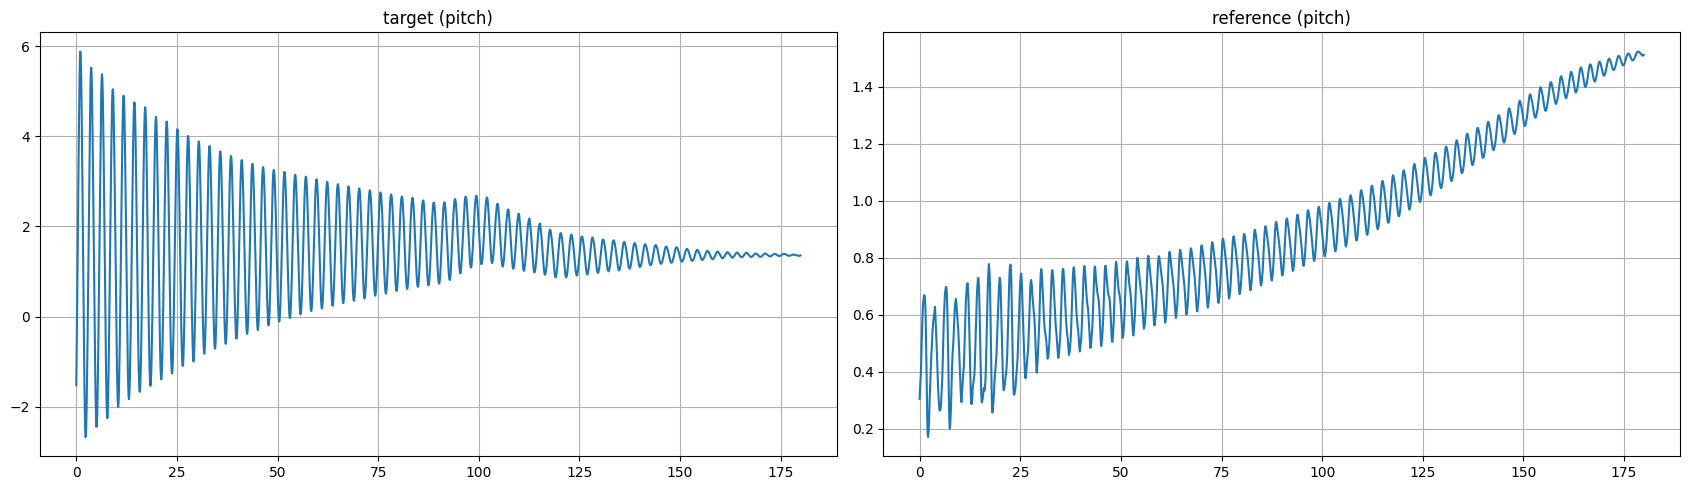

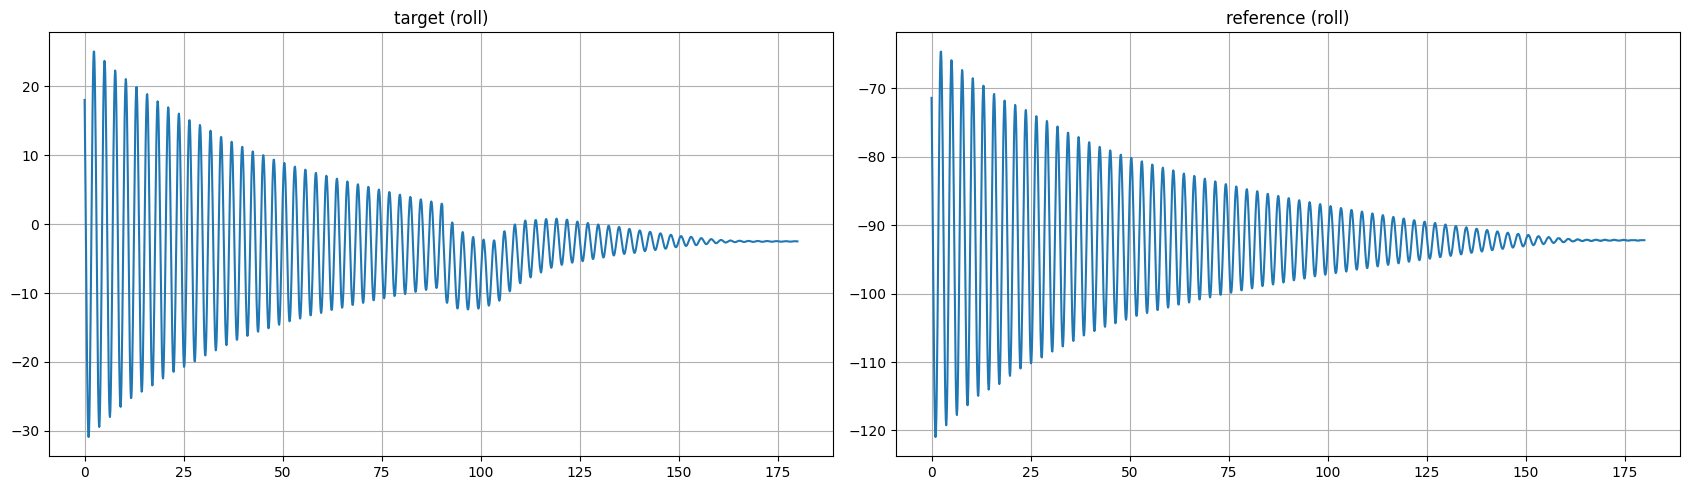

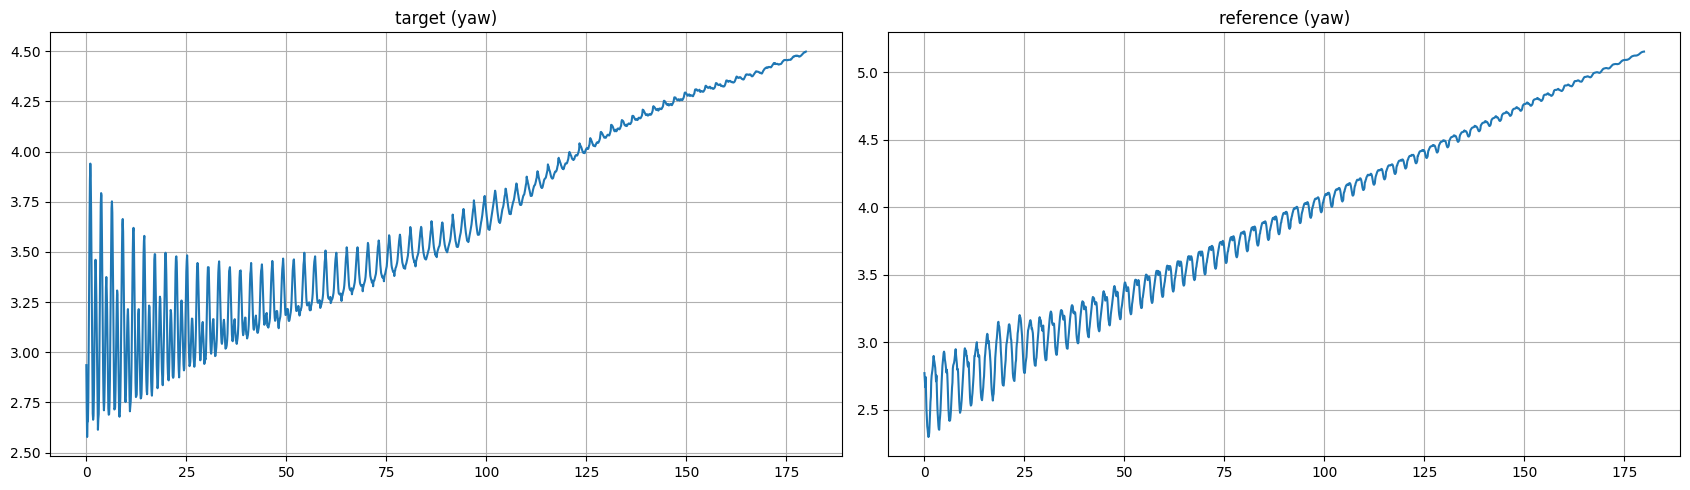

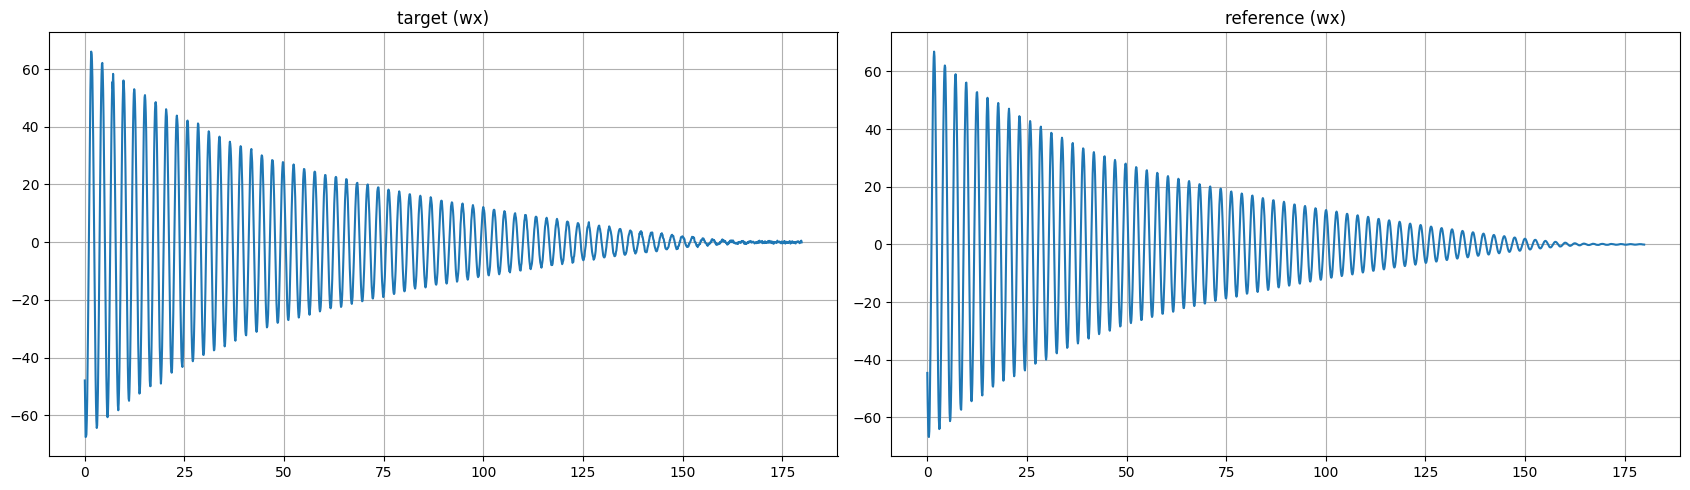

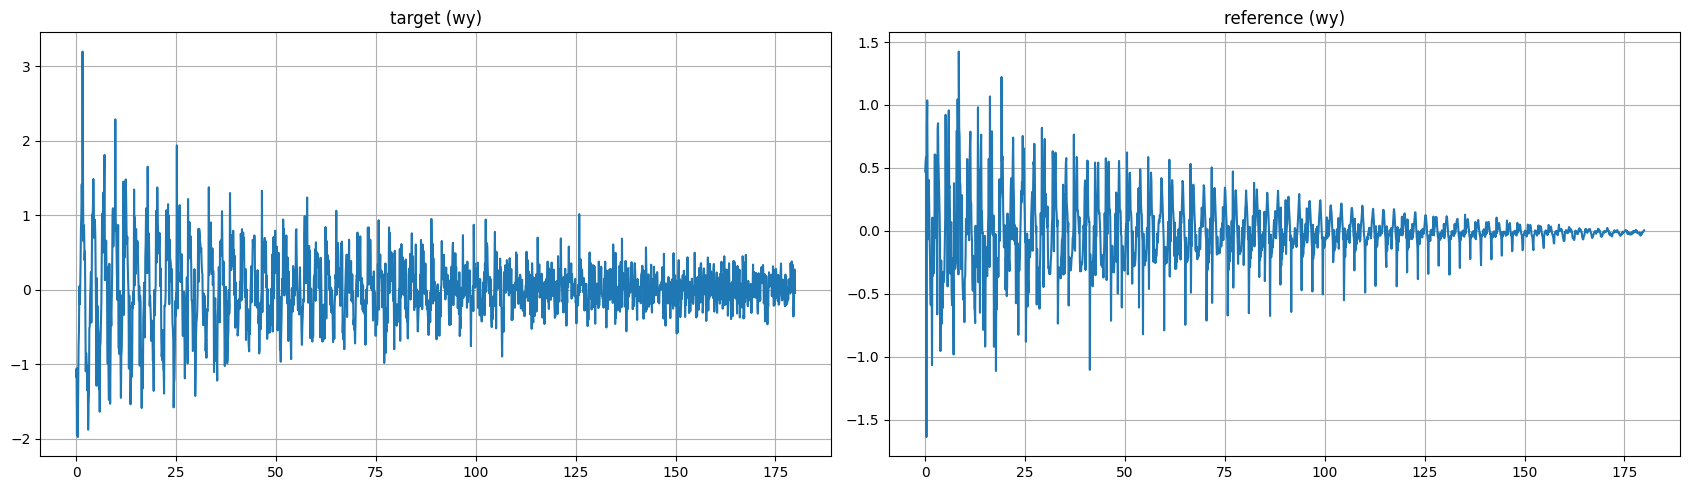

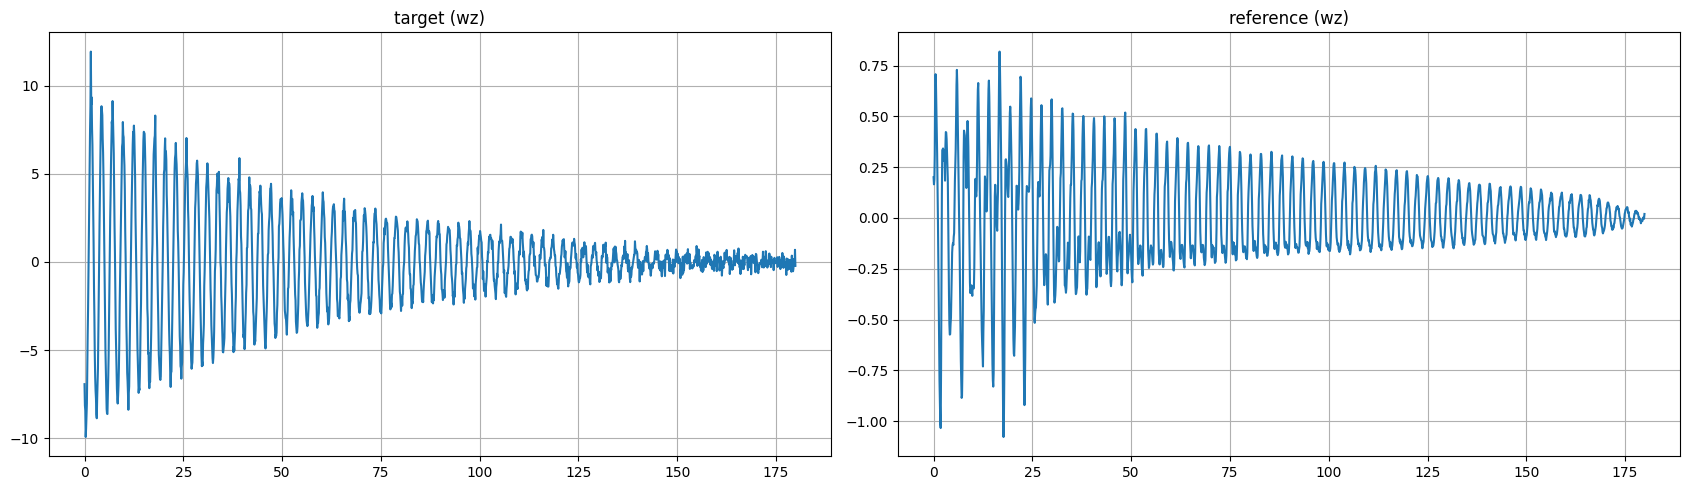

In [50]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df.loc[~df.static][f'target_{var}'], 
        f'reference ({var})': df.loc[~df.static][f'ref_{var}']
    }, time=df.loc[~df.static].time, figsize=(17, 5))

# REMOVENDO A BARRIGUINHA

In [51]:
def clearBarriguinha(df, undesired=(45, 80)):
    # Desempacota os limites do intervalo
    start_time, end_time = undesired
    
    # 1. Pega os dados ANTES da barriguinha
    df_before = df[df['time'] < start_time].copy()
    
    # 2. Pega os dados DEPOIS da barriguinha
    df_after = df[df['time'] > end_time].copy()
    
    # 3. Calcula o tamanho do gap (duração da barriguinha)
    gap_duration = end_time - start_time
    
    # 4. Desloca o tempo dos dados 'depois' para trás, fechando o buraco
    df_after['time'] = df_after['time'] - gap_duration
    
    # 5. Junta os dois pedaços e reseta o índice
    df_cleaned = pd.concat([df_before, df_after]).reset_index(drop=True)
    
    return df_cleaned



test = json.loads(open('../info.json', 'r', encoding='utf-8').read())['target']['test']
axis = json.loads(open('../info.json', 'r', encoding='utf-8').read())['target']['axis']

interval = json.loads(open(f'files/test{test}/rolling_{axis}/info.json', 'r', encoding='utf-8').read()).get('belly')
print(interval)

df = clearBarriguinha(df, interval)
df.head()

[80, 125]


,time,target_wz,target_tmp,target_pitch,target_e,target_ay,target_ax,target_wx,target_wy,target_az,target_roll,target_yaw,static,ref_sample_time,ref_wz,ref_pitch,ref_q0,ref_q1,ref_ay,ref_wx,ref_ax,ref_q2,ref_wy,ref_la_pos_mon_d,ref_az,ref_roll,ref_yaw,ref_q3
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,18.043,2.936,False,605000000.0,0.200478,0.304871,-0.8118,0.5835,9.59,-44.581846,0.06400,0.01196,0.471315,-0.5252,0.8262,-71.390541,2.771970,-0.02120
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,12.732,2.725,False,705000000.0,0.165413,0.337243,-0.7843,0.6199,10.54,-54.981030,0.09128,0.01243,0.546086,-0.4685,0.8149,-76.661753,2.723841,-0.02047
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,6.586,2.578,False,805000000.0,0.189592,0.366750,-0.7505,0.6604,11.46,-62.337808,0.12330,0.01297,0.585563,-0.4231,0.7793,-82.677810,2.667691,-0.01959
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,-0.016,2.655,False,905000000.0,0.310085,0.387721,-0.7116,0.7021,12.17,-66.291217,0.19090,0.01440,-1.635795,-0.3990,0.7029,-89.209529,2.743322,-0.01942
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,-6.779,2.656,False,5000000.0,0.653172,0.442381,-0.6696,0.7424,12.51,-66.806879,0.17590,0.01442,0.789536,-0.4016,0.5932,-95.913135,2.624720,-0.01821


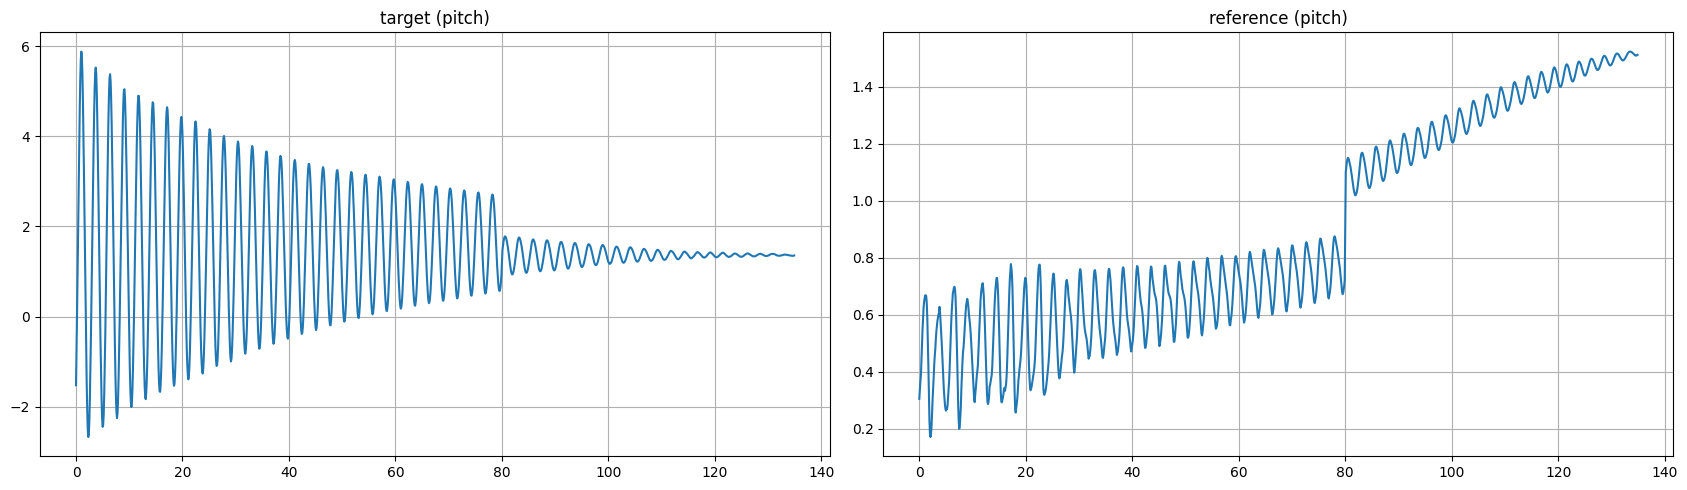

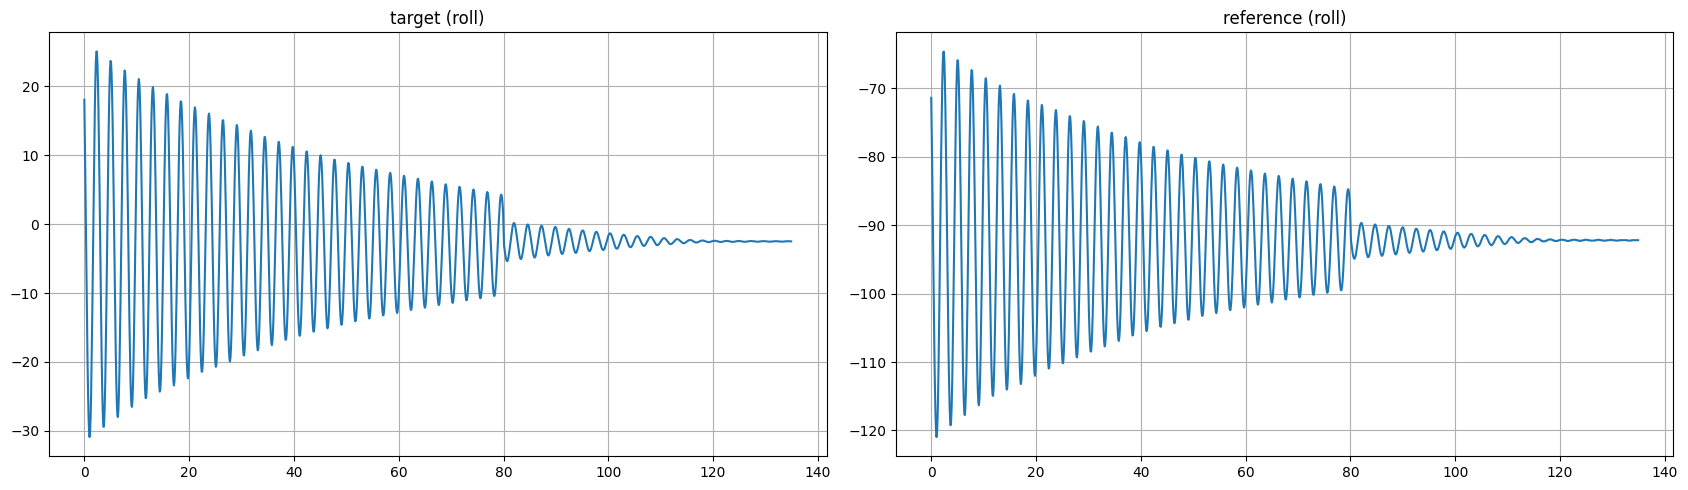

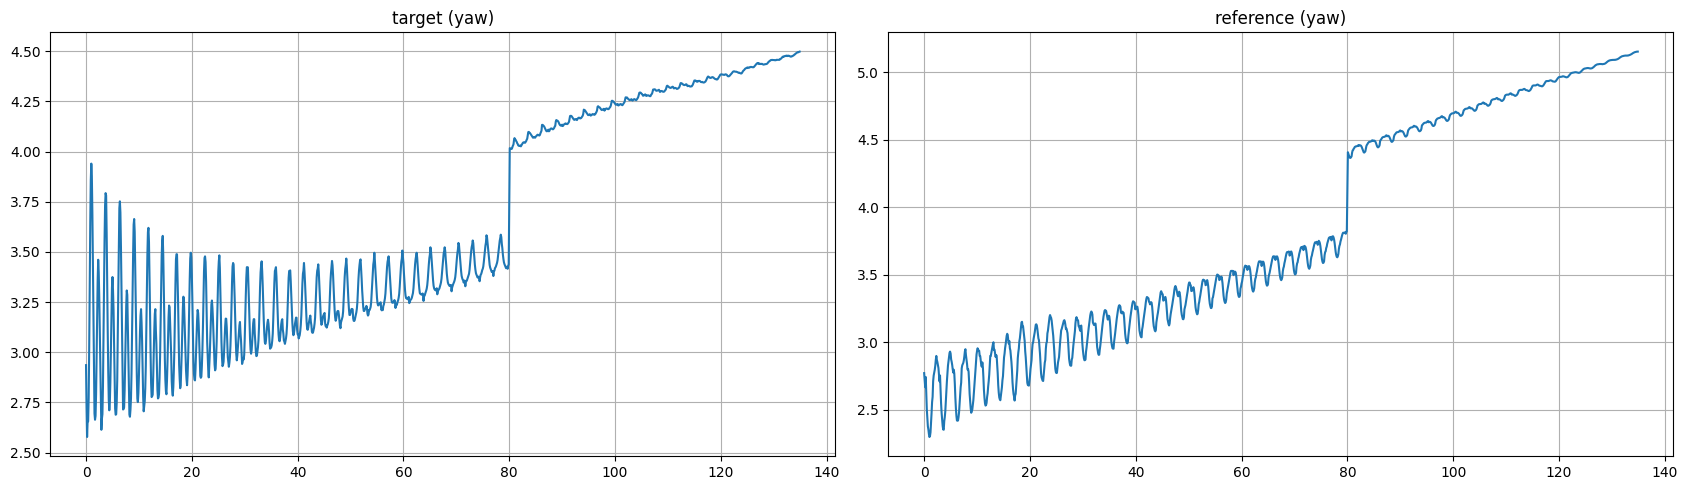

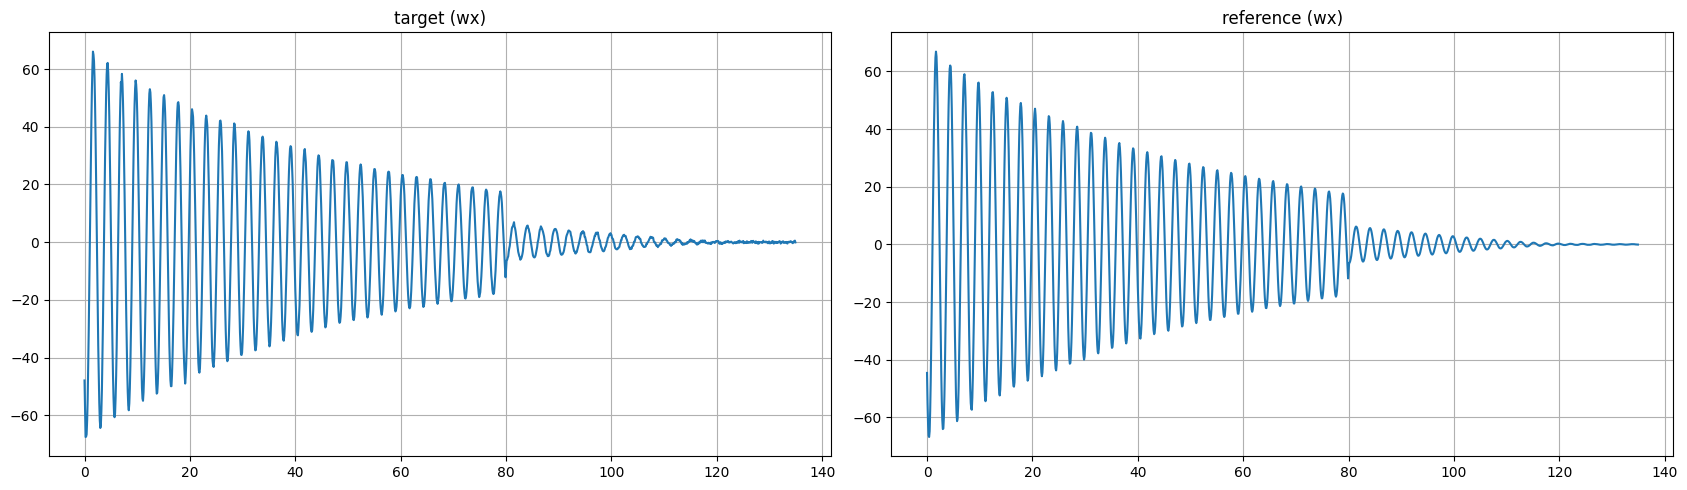

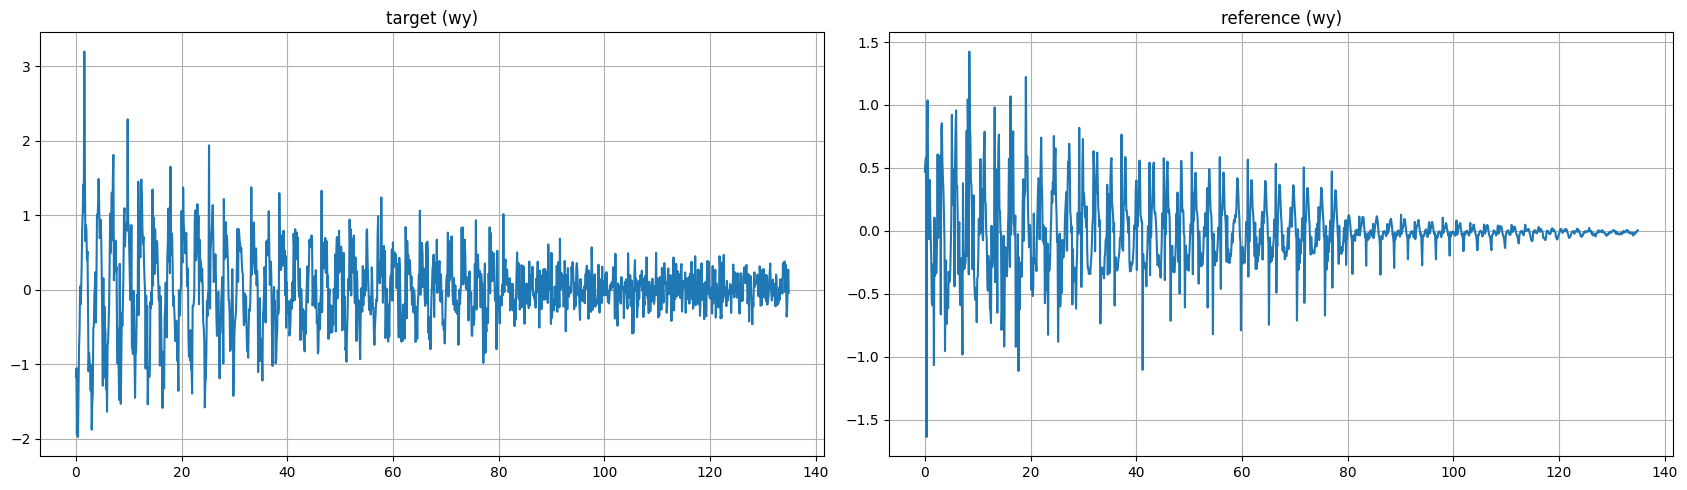

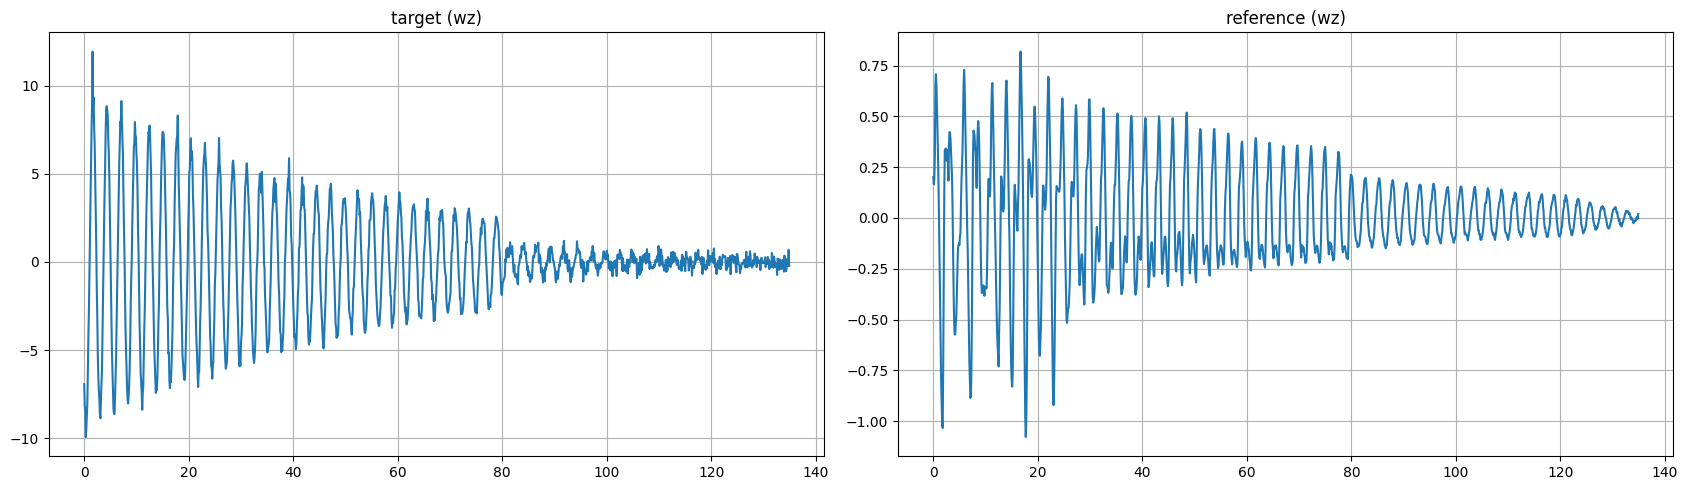

In [52]:
for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df.loc[~df.static][f'target_{var}'], 
        f'reference ({var})': df.loc[~df.static][f'ref_{var}']
    }, time=df.loc[~df.static].time, figsize=(17, 5))

# SALVANDO DADOS

In [53]:
os.makedirs('files', exist_ok=True)
df.to_csv('files/output.csv', index=None)